# 4. Univariate Exploratory Data Analysis

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"
REPORT_DIR = Path("../reports/eda")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR   :", RAW_DIR.resolve())
print("REPORT_DIR:", REPORT_DIR.resolve())


RAW_DIR   : C:\Users\beelt\Documents\collections_case_candidate\data\raw
REPORT_DIR: C:\Users\beelt\Documents\collections_case_candidate\reports\eda


## 4.1 Load datasets

The datasets are loaded independently so that customer-level and interaction-level distributions are not mixed.

In [2]:
def find_file(candidates, roots=(RAW_DIR, DATA_DIR, Path("."))):
    for root in roots:
        for candidate in candidates:
            path = root / candidate
            if path.exists():
                return path
    return None

customer_path = find_file(["collections_queue_sep2026.csv"])
whatsapp_path = find_file(["whatsapp_collections_history.csv"])

datasets = {}

if customer_path:
    datasets[customer_path.stem] = pd.read_csv(customer_path)
if whatsapp_path and whatsapp_path != customer_path:
    datasets[whatsapp_path.stem] = pd.read_csv(whatsapp_path)

if not datasets:
    raise FileNotFoundError("No analytical CSV was found. Update the candidate filenames in this cell.")

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


collections_queue_sep2026: 10,658 rows × 10 columns
whatsapp_collections_history: 75,406 rows × 17 columns


## 4.2 Dataset overview

Provides a structural snapshot of each dataset without business interpretation.

In [3]:
dataset_overview = pd.DataFrame([
    {
        "dataset": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_rows_pct": df.duplicated().mean() * 100,
        "memory_mb": df.memory_usage(deep=True).sum() / 1024**2,
    }
    for name, df in datasets.items()
])

display(dataset_overview)


,dataset,rows,columns,duplicate_rows,duplicate_rows_pct,memory_mb
0,collections_queue_sep2026,10658,10,0,0.0000,2.2566
1,whatsapp_collections_history,75406,17,0,0.0000,34.8747


## 4.3 Variable inventory

Summarizes dtype, completeness, cardinality, uniqueness, and constant/all-missing variables for every observed column.

In [4]:
variable_rows = []
for dataset_name, df in datasets.items():
    for variable in df.columns:
        s = df[variable]
        non_null = int(s.notna().sum())
        n_unique = int(s.nunique(dropna=True))
        variable_rows.append({
            "dataset": dataset_name,
            "variable": variable,
            "dtype": str(s.dtype),
            "rows": len(s),
            "non_null": non_null,
            "missing": int(s.isna().sum()),
            "missing_pct": s.isna().mean() * 100,
            "n_unique": n_unique,
            "unique_pct_non_null": (n_unique / non_null * 100) if non_null else np.nan,
            "is_constant": n_unique <= 1 and non_null > 0,
            "is_all_missing": non_null == 0,
        })

variable_inventory = pd.DataFrame(variable_rows)
display(variable_inventory.sort_values(["dataset", "variable"]).reset_index(drop=True))


,dataset,variable,dtype,rows,non_null,missing,missing_pct,n_unique,unique_pct_non_null,is_constant,is_all_missing
0,collections_queue_sep2026,account_age_months,int64,10658,10658,0,0.0000,40,0.3753,False,False
1,collections_queue_sep2026,customer_id,object,10658,10658,0,0.0000,10658,100.0000,False,False
2,collections_queue_sep2026,days_past_due_on_2026-09-01,int64,10658,10658,0,0.0000,60,0.5630,False,False
3,collections_queue_sep2026,days_since_last_app_login,int64,10658,10658,0,0.0000,165,1.5481,False,False
4,collections_queue_sep2026,in_collections_since,object,10658,10658,0,0.0000,89,0.8351,False,False
5,collections_queue_sep2026,monthly_salary_brl,float64,10658,10658,0,0.0000,617,5.7891,False,False
6,collections_queue_sep2026,n_prior_transactions,int64,10658,10658,0,0.0000,40,0.3753,False,False
7,collections_queue_sep2026,outstanding_balance_brl,float64,10658,10658,0,0.0000,9250,86.7893,False,False
8,collections_queue_sep2026,payday_day_of_month,int64,10658,10658,0,0.0000,7,0.0657,False,False
9,collections_queue_sep2026,state_uf,object,10658,10658,0,0.0000,27,0.2533,False,False


## 4.4 Missingness

Shows missing-value concentration by variable. At this stage, missingness is described rather than interpreted as a business problem.

In [5]:
for dataset_name, df in datasets.items():
    display(Markdown(f"### {dataset_name}"))
    missing = (df.isna().mean().mul(100).sort_values(ascending=False).rename("missing_pct").to_frame())
    display(missing)

    plot_data = missing[missing["missing_pct"] > 0].sort_values("missing_pct")
    if not plot_data.empty:
        plt.figure(figsize=(10, max(4, len(plot_data) * 0.35)))
        bars = plt.barh(plot_data.index, plot_data["missing_pct"])
        plt.xlabel("Missing (%)")
        plt.ylabel("Variable")
        plt.title(f"Missingness — {dataset_name}")
        for bar, value in zip(bars, plot_data["missing_pct"]):
            plt.text(value, bar.get_y() + bar.get_height()/2, f" {value:.1f}%", va="center")
        plt.tight_layout()
        plt.show()


### collections_queue_sep2026

,missing_pct
customer_id,0.0000
in_collections_since,0.0000
days_past_due_on_2026-09-01,0.0000
outstanding_balance_brl,0.0000
monthly_salary_brl,0.0000
payday_day_of_month,0.0000
n_prior_transactions,0.0000
account_age_months,0.0000
days_since_last_app_login,0.0000
state_uf,0.0000


### whatsapp_collections_history

,missing_pct
message_id,0.0000
customer_id,0.0000
sent_at,0.0000
template,0.0000
n_msgs_last_14d,0.0000
days_past_due,0.0000
outstanding_balance_brl,0.0000
monthly_salary_brl,0.0000
payday_day_of_month,0.0000
n_prior_transactions,0.0000


## 4.5 Numeric variables

Describes location, dispersion, tails, zero mass, negative values, and repeated-value concentration for numeric variables.

In [6]:
def numeric_summary(series):
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()
    if valid.empty:
        return {}
    vc = valid.value_counts(normalize=True)
    return {
        "count": len(valid),
        "missing_pct": s.isna().mean() * 100,
        "n_unique": valid.nunique(),
        "mean": valid.mean(),
        "std": valid.std(),
        "min": valid.min(),
        "p01": valid.quantile(.01),
        "p05": valid.quantile(.05),
        "p25": valid.quantile(.25),
        "median": valid.median(),
        "p75": valid.quantile(.75),
        "p95": valid.quantile(.95),
        "p99": valid.quantile(.99),
        "max": valid.max(),
        "zero_pct": valid.eq(0).mean() * 100,
        "negative_pct": valid.lt(0).mean() * 100,
        "most_common_value": vc.index[0],
        "most_common_pct": vc.iloc[0] * 100,
    }

numeric_rows = []
for dataset_name, df in datasets.items():
    for variable in df.select_dtypes(include=np.number).columns:
        numeric_rows.append({"dataset": dataset_name, "variable": variable, **numeric_summary(df[variable])})

numeric_summary_df = pd.DataFrame(numeric_rows)
display(numeric_summary_df)


,dataset,variable,count,missing_pct,n_unique,mean,std,min,p01,p05,p25,median,p75,p95,p99,max,zero_pct,negative_pct,most_common_value,most_common_pct
0,collections_queue_sep2026,days_past_due_on_2026-09-01,10658,0.0000,60,15.6046,19.3428,0.0000,0.0000,0.0000,0.0000,4.0000,31.0000,54.0000,59.0000,60.0000,46.9131,0.0000,0.0000,46.9131
1,collections_queue_sep2026,outstanding_balance_brl,10658,0.0000,9250,833.7407,490.8182,50.6800,136.2710,250.3300,445.1375,727.8300,"1,121.5625","1,921.4665","2,000.0000","2,000.0000",0.0000,0.0000,"2,000.0000",4.1190
2,collections_queue_sep2026,monthly_salary_brl,10658,0.0000,617,"2,671.1447","1,248.3034","1,200.0000","1,200.0000","1,200.0000","1,760.0000","2,410.0000","3,280.0000","5,030.0000","6,885.8000","14,390.0000",0.0000,0.0000,"1,200.0000",6.6710
3,collections_queue_sep2026,payday_day_of_month,10658,0.0000,7,12.9656,9.2785,1.0000,1.0000,1.0000,5.0000,10.0000,20.0000,30.0000,30.0000,30.0000,0.0000,0.0000,5.0000,35.4100
4,collections_queue_sep2026,n_prior_transactions,10658,0.0000,40,8.9772,8.3058,1.0000,1.0000,1.0000,3.0000,6.0000,12.0000,27.0000,40.0000,40.0000,0.0000,0.0000,1.0000,11.6814
5,collections_queue_sep2026,account_age_months,10658,0.0000,40,9.2645,7.1065,1.0000,1.0000,1.0000,4.0000,8.0000,13.0000,24.0000,33.0000,40.0000,0.0000,0.0000,1.0000,9.4014
6,collections_queue_sep2026,days_since_last_app_login,10658,0.0000,165,24.8908,24.4229,0.0000,0.0000,1.0000,7.0000,18.0000,35.0000,73.0000,112.0000,235.0000,1.2573,0.0000,1.0000,4.3066
7,whatsapp_collections_history,n_msgs_last_14d,75406,0.0000,11,2.1671,1.7159,0.0000,0.0000,0.0000,1.0000,2.0000,3.0000,5.0000,7.0000,10.0000,19.0171,0.0000,1.0000,21.5633
8,whatsapp_collections_history,days_past_due,75406,0.0000,60,17.0279,14.3575,1.0000,1.0000,1.0000,6.0000,12.0000,25.0000,49.0000,58.0000,60.0000,0.0000,0.0000,1.0000,5.0938
9,whatsapp_collections_history,outstanding_balance_brl,75406,0.0000,11510,823.3953,486.6351,51.6100,129.2200,250.2900,434.2100,725.1000,"1,107.4000","1,899.9400","2,000.0000","2,000.0000",0.0000,0.0000,"2,000.0000",4.0421


### 4.5.1 Numeric distributions

### Numeric variables — collections_queue_sep2026

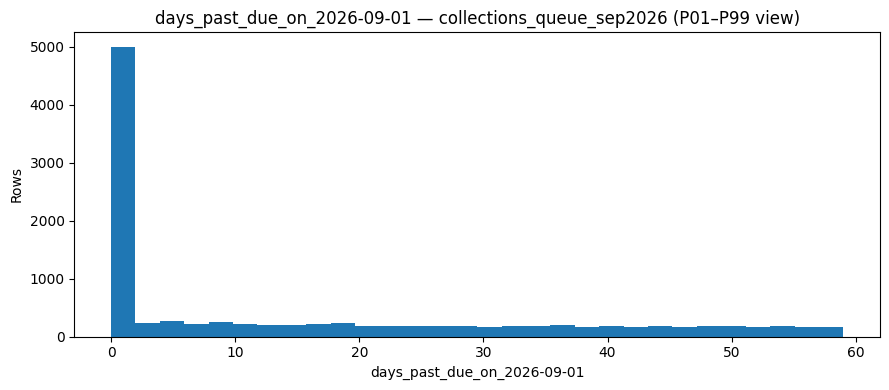

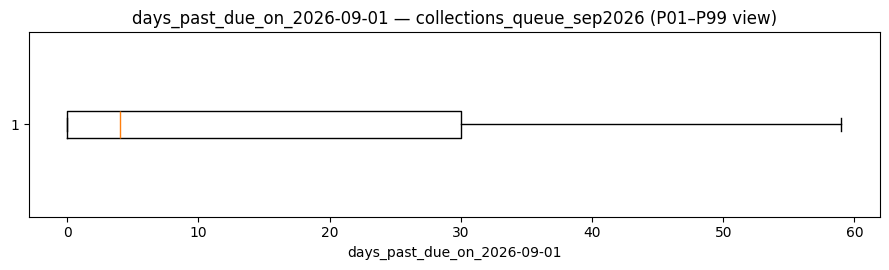

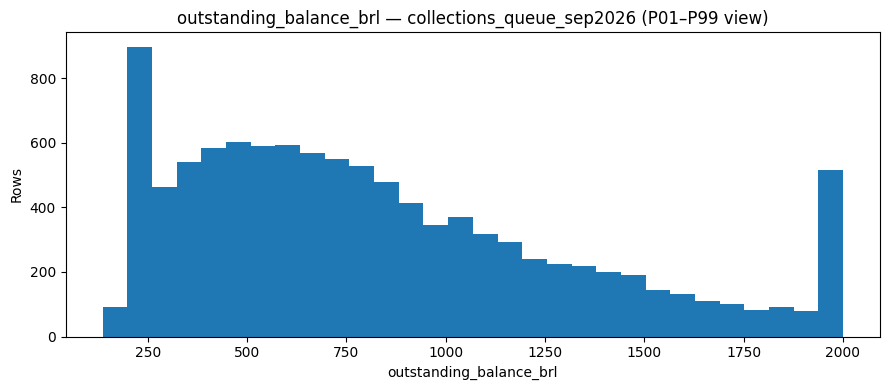

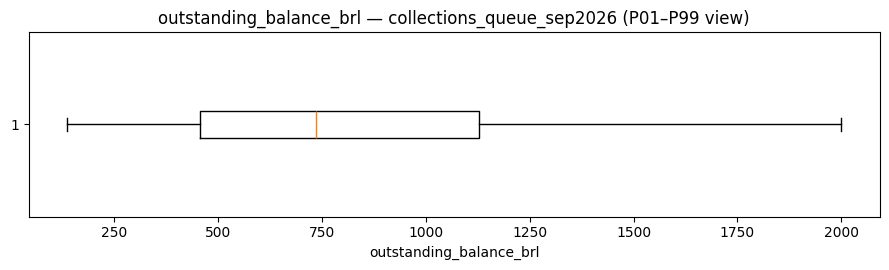

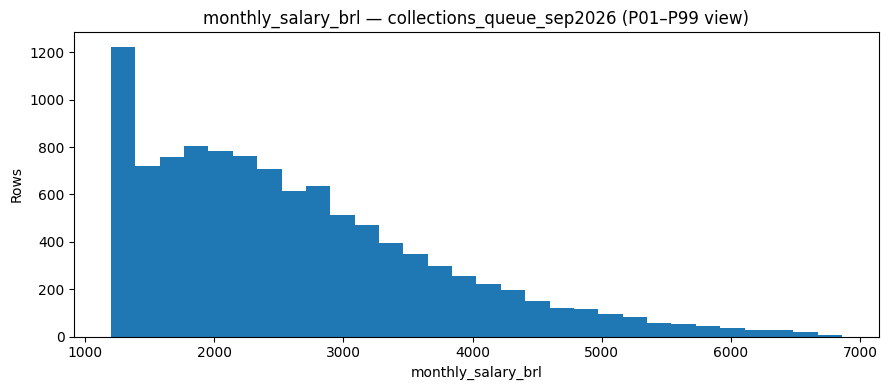

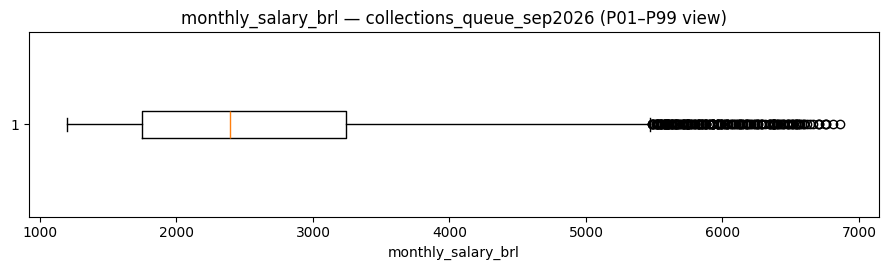

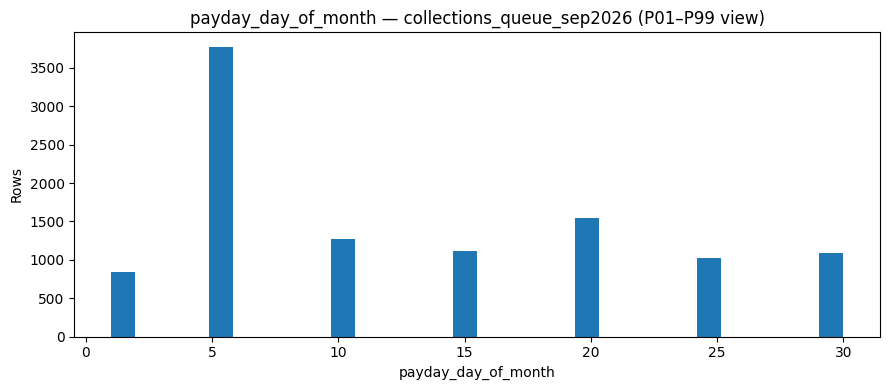

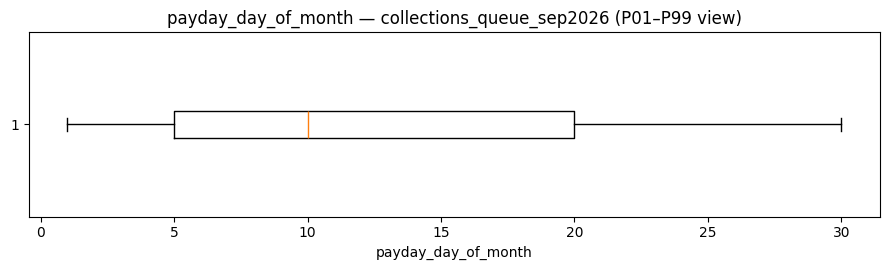

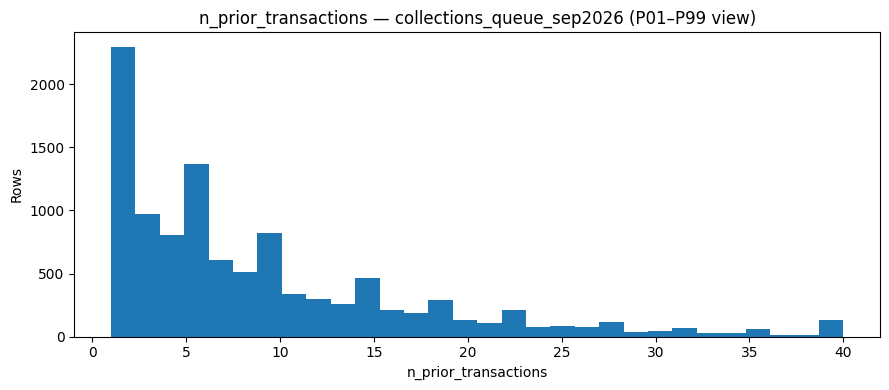

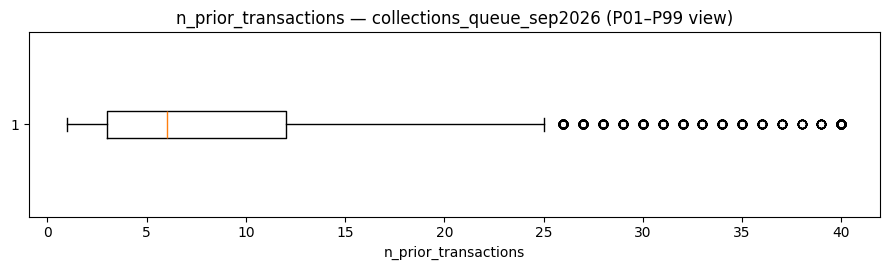

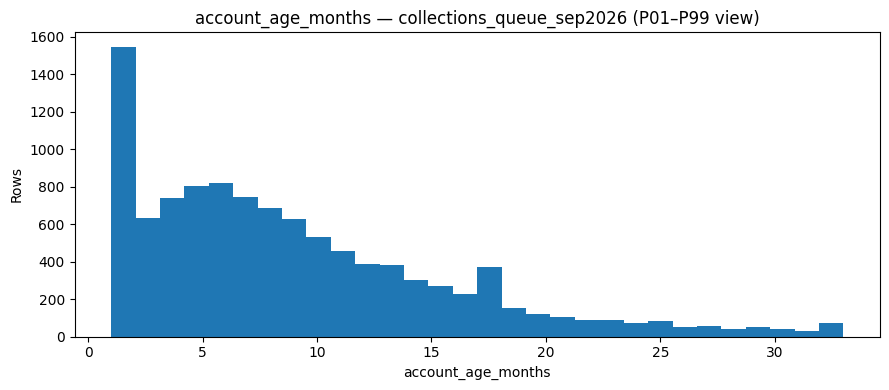

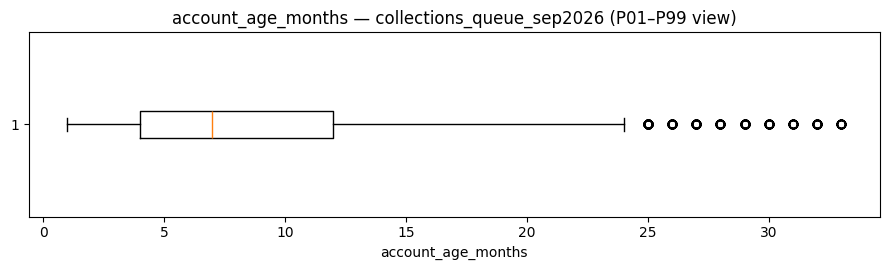

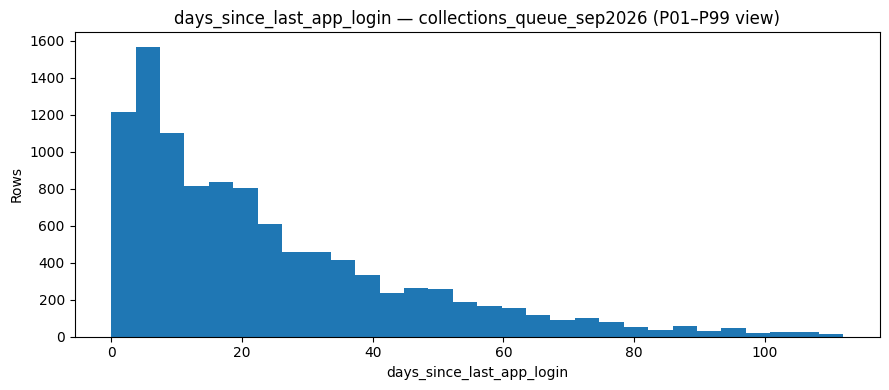

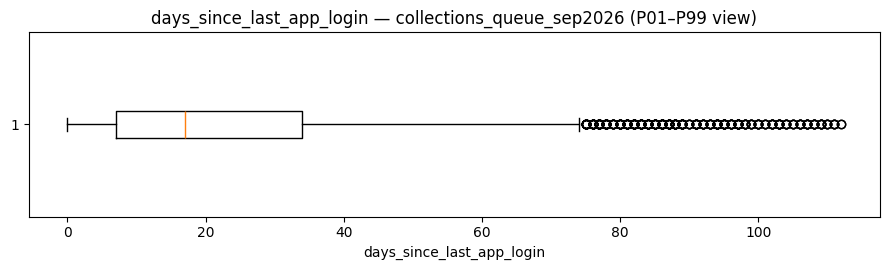

### Numeric variables — whatsapp_collections_history

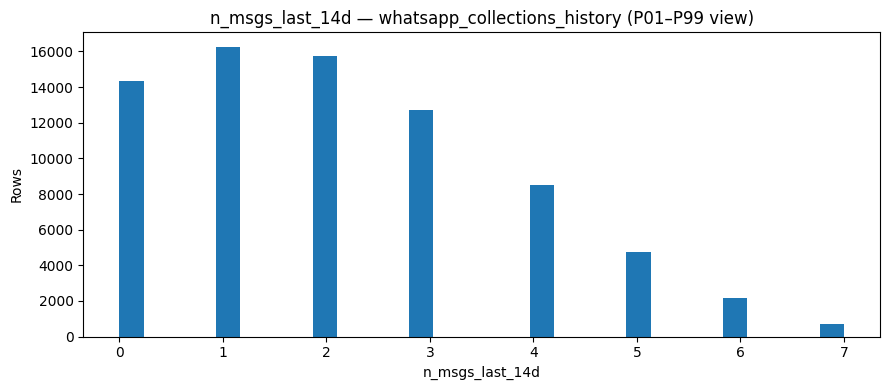

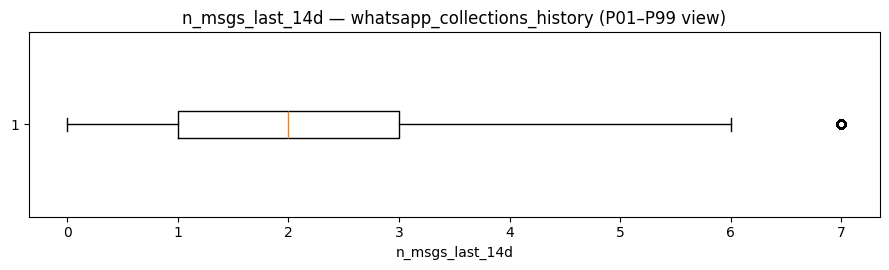

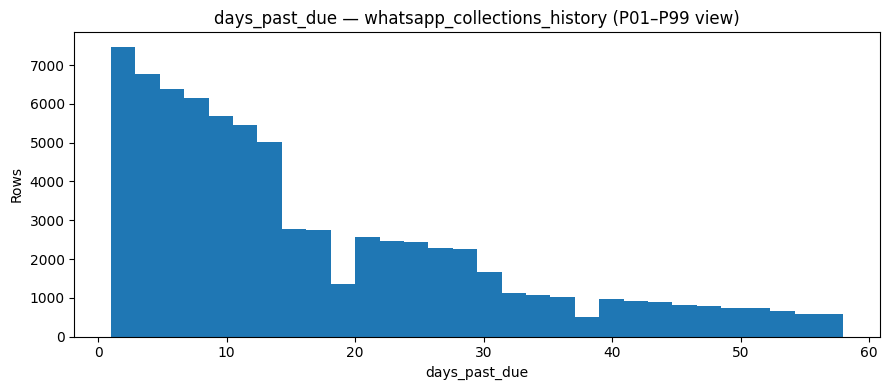

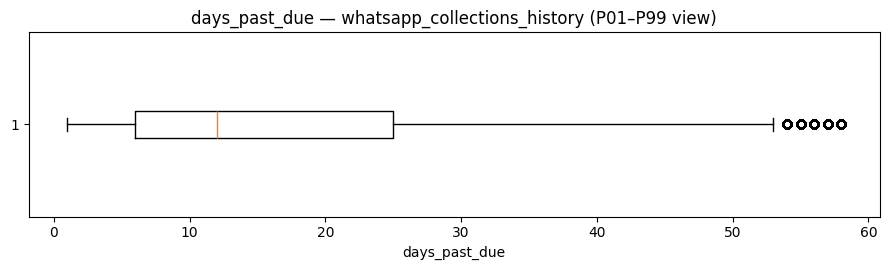

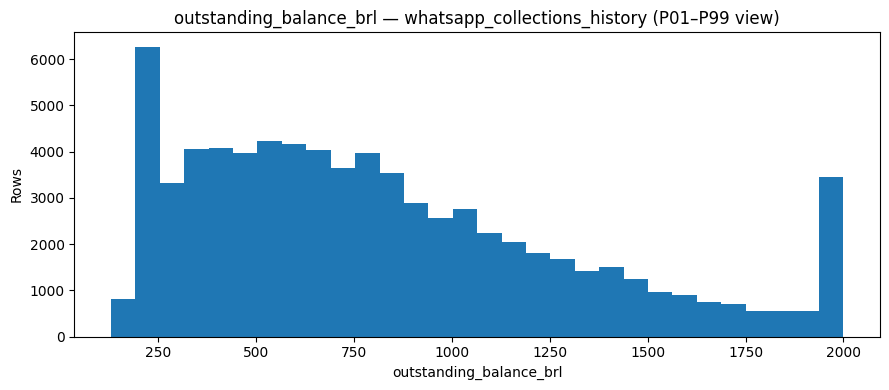

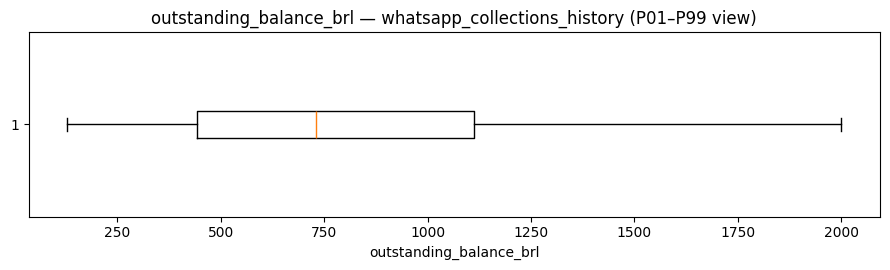

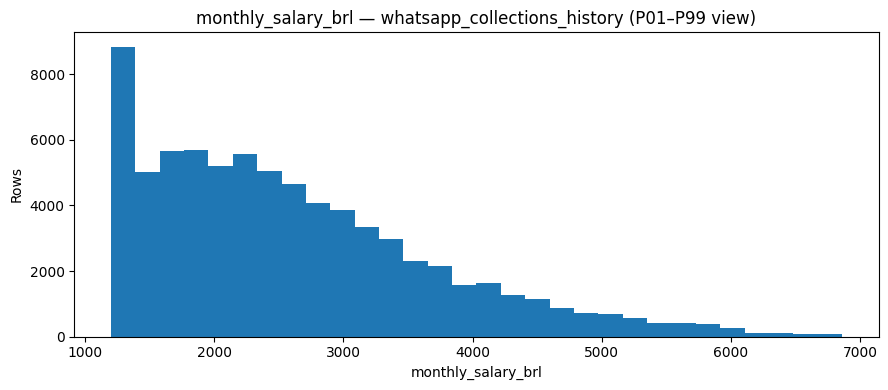

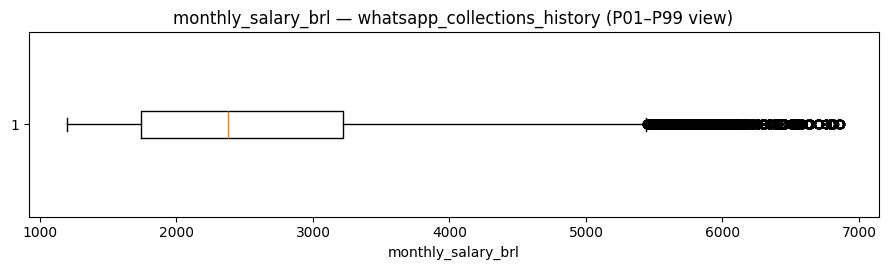

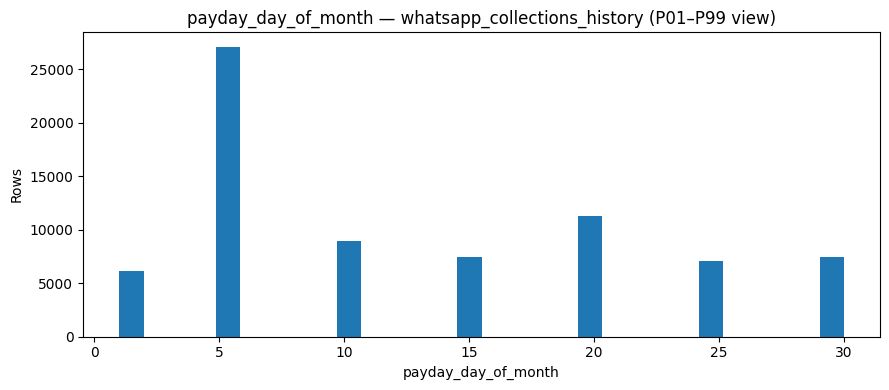

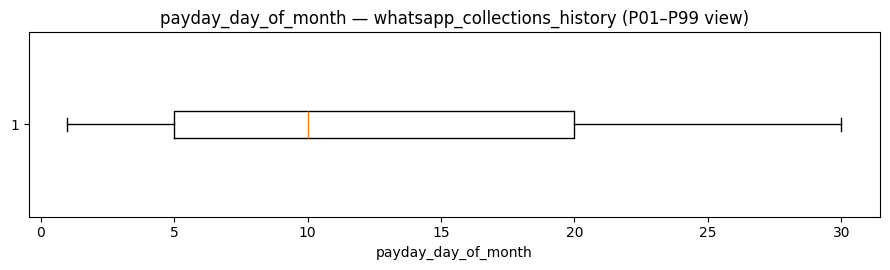

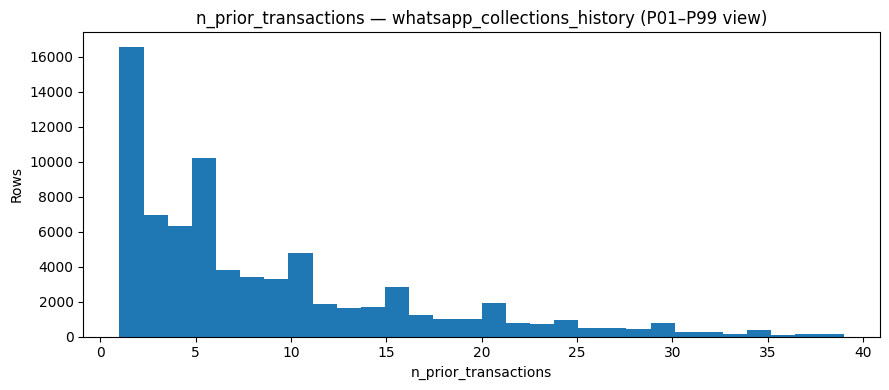

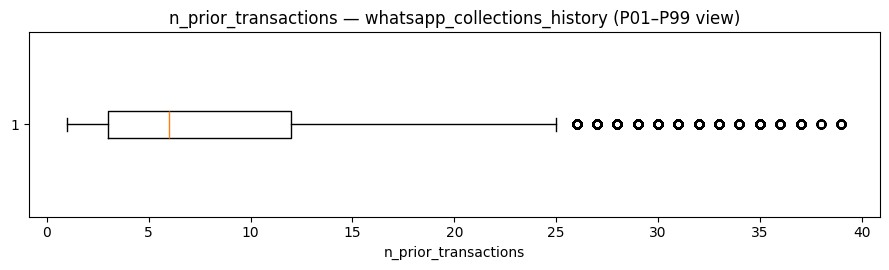

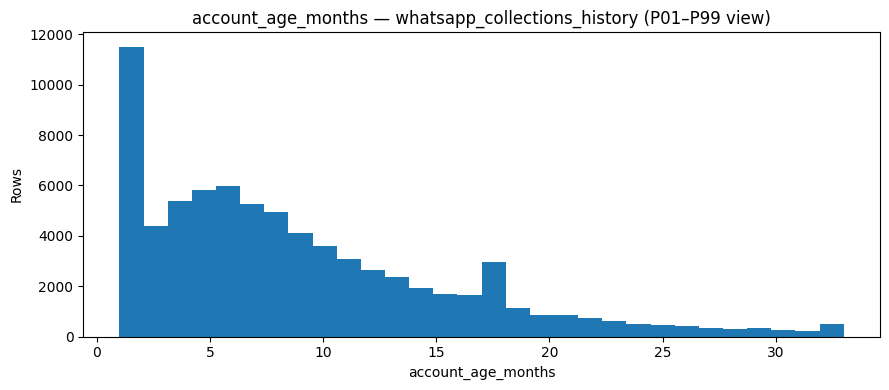

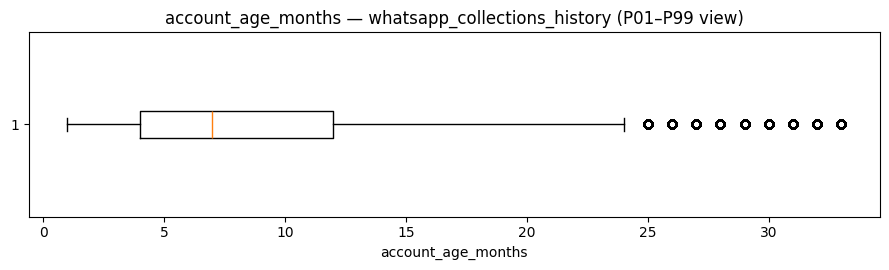

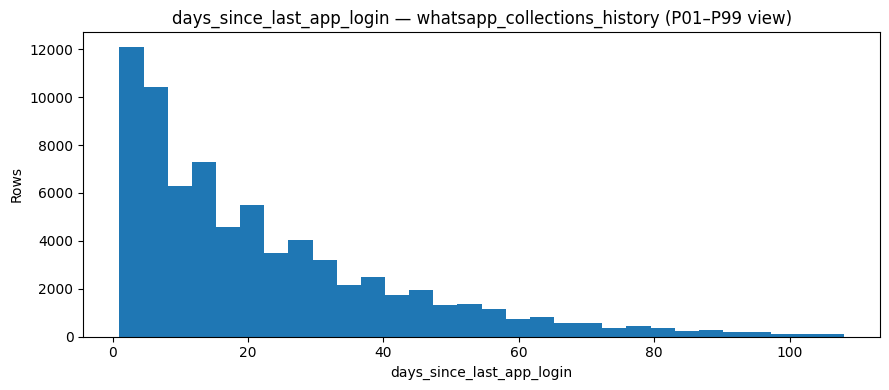

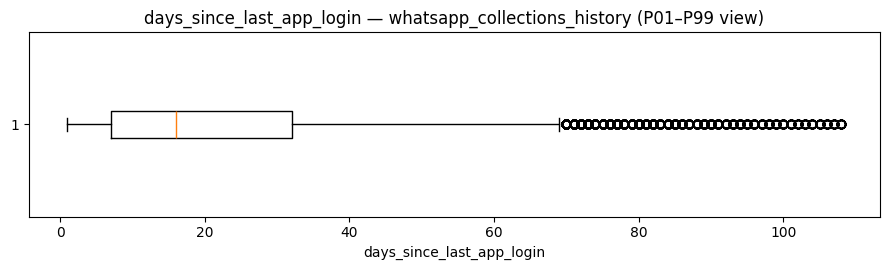

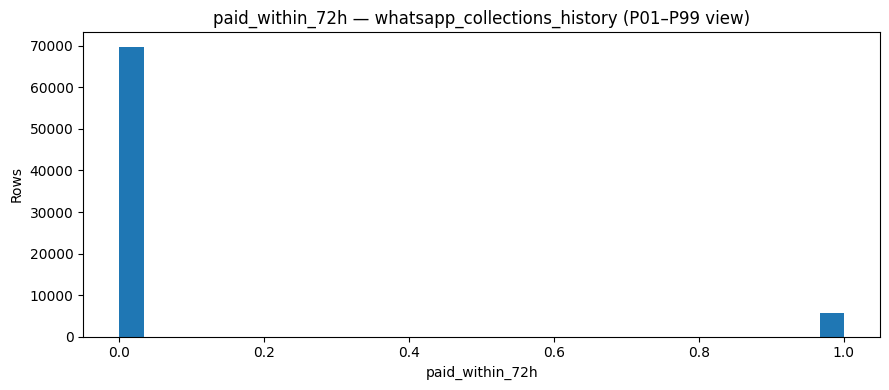

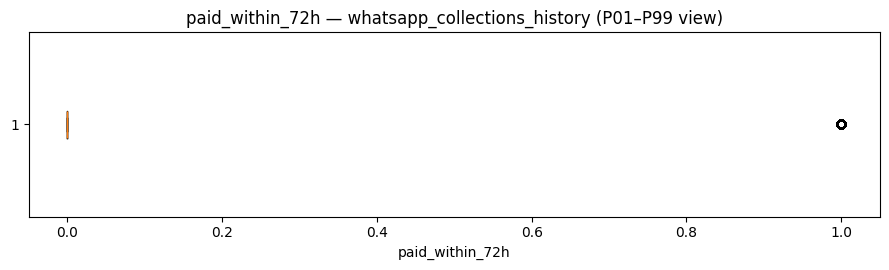

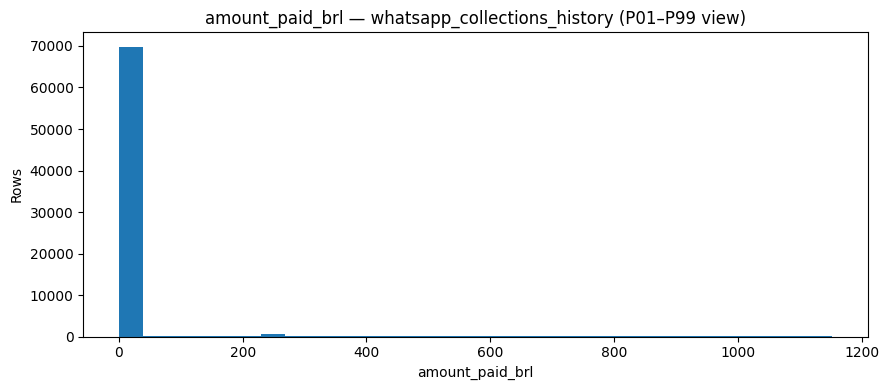

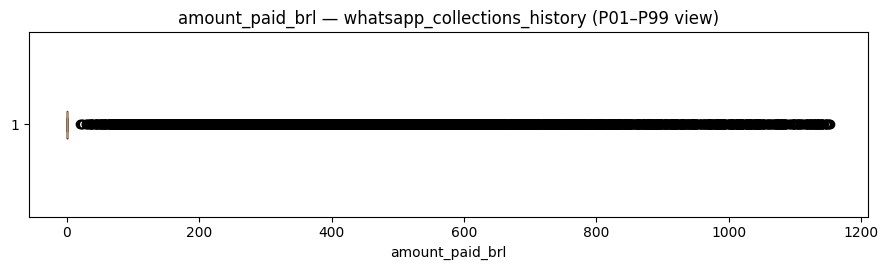

In [7]:
def plot_numeric_distribution(series, variable, dataset_name):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return
    lo, hi = s.quantile([.01, .99])
    plot_s = s[(s >= lo) & (s <= hi)] if lo < hi else s

    plt.figure(figsize=(9, 4))
    plt.hist(plot_s, bins=30)
    plt.xlabel(variable)
    plt.ylabel("Rows")
    plt.title(f"{variable} — {dataset_name} (P01–P99 view)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 2.8))
    plt.boxplot(plot_s, vert=False)
    plt.xlabel(variable)
    plt.title(f"{variable} — {dataset_name} (P01–P99 view)")
    plt.tight_layout()
    plt.show()

for dataset_name, df in datasets.items():
    display(Markdown(f"### Numeric variables — {dataset_name}"))
    for variable in df.select_dtypes(include=np.number).columns:
        plot_numeric_distribution(df[variable], variable, dataset_name)


## 4.6 Categorical and low-cardinality variables

In [8]:
def categorical_summary(series):
    valid = series.dropna()
    if valid.empty:
        return {}
    shares = valid.value_counts(normalize=True)
    counts = valid.value_counts()
    return {
        "count": len(valid),
        "missing_pct": series.isna().mean() * 100,
        "n_unique": valid.nunique(),
        "mode": counts.index[0],
        "mode_count": counts.iloc[0],
        "mode_pct": shares.iloc[0] * 100,
        "top_3_pct": shares.iloc[:3].sum() * 100,
        "top_5_pct": shares.iloc[:5].sum() * 100,
        "top_10_pct": shares.iloc[:10].sum() * 100,
    }

categorical_rows = []
for dataset_name, df in datasets.items():
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
    for variable in categorical_cols:
        categorical_rows.append({"dataset": dataset_name, "variable": variable, **categorical_summary(df[variable])})

categorical_summary_df = pd.DataFrame(categorical_rows)
display(categorical_summary_df)


,dataset,variable,count,missing_pct,n_unique,mode,mode_count,mode_pct,top_3_pct,top_5_pct,top_10_pct
0,collections_queue_sep2026,customer_id,10658,0.0000,10658,C000002,1,0.0094,0.0281,0.0469,0.0938
1,collections_queue_sep2026,in_collections_since,10658,0.0000,89,2026-09-14,192,1.8015,5.1886,8.5194,16.7198
2,collections_queue_sep2026,state_uf,10658,0.0000,27,SP,2359,22.1336,40.1764,52.8898,74.3291
3,whatsapp_collections_history,message_id,75406,0.0000,75406,M0000001,1,0.0013,0.0040,0.0066,0.0133
4,whatsapp_collections_history,customer_id,75406,0.0000,11724,C005915,21,0.0278,0.0822,0.1339,0.2599
5,whatsapp_collections_history,sent_at,75406,0.0000,39466,2026-07-23 10:11,12,0.0159,0.0424,0.0690,0.1300
6,whatsapp_collections_history,template,75406,0.0000,4,friendly_reminder,24404,32.3635,91.7540,100.0000,100.0000
7,whatsapp_collections_history,state_uf,75406,0.0000,27,SP,16347,21.6786,39.5419,52.5515,74.4026
8,whatsapp_collections_history,delivery_status,75406,0.0000,4,delivered,63543,84.2678,97.2297,100.0000,100.0000
9,whatsapp_collections_history,interaction,75406,0.0000,4,none,45201,59.9435,93.9594,100.0000,100.0000


### 4.6.1 Category distributions

Displays the most frequent values and their share of total rows, including missing values as an explicit display category.

### Categorical variables — collections_queue_sep2026

customer_id: chart skipped (10,658 unique values)
in_collections_since: chart skipped (89 unique values)


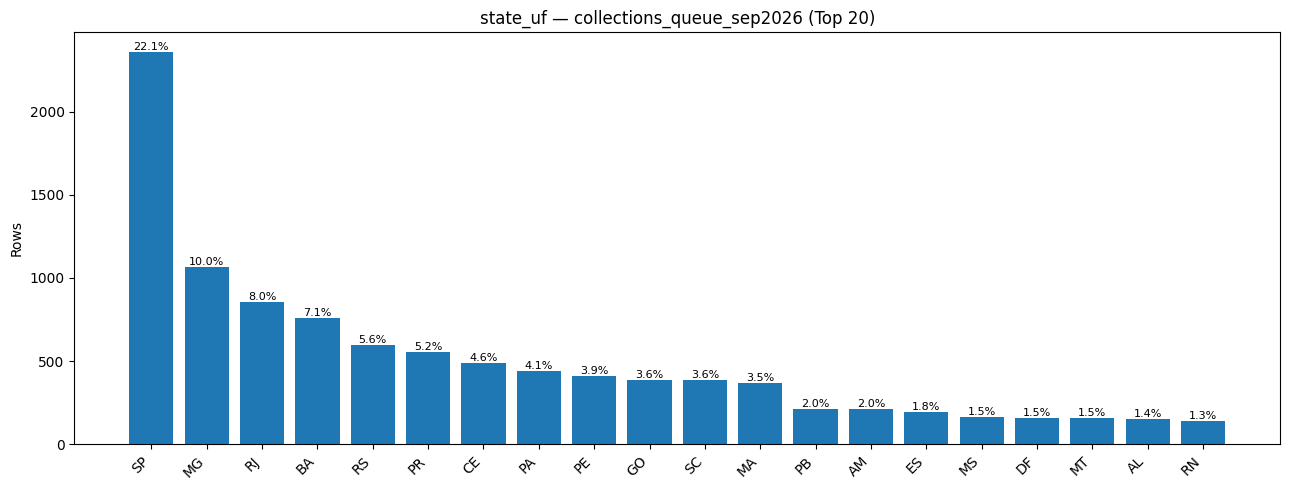

### Categorical variables — whatsapp_collections_history

message_id: chart skipped (75,406 unique values)
customer_id: chart skipped (11,724 unique values)
sent_at: chart skipped (39,466 unique values)


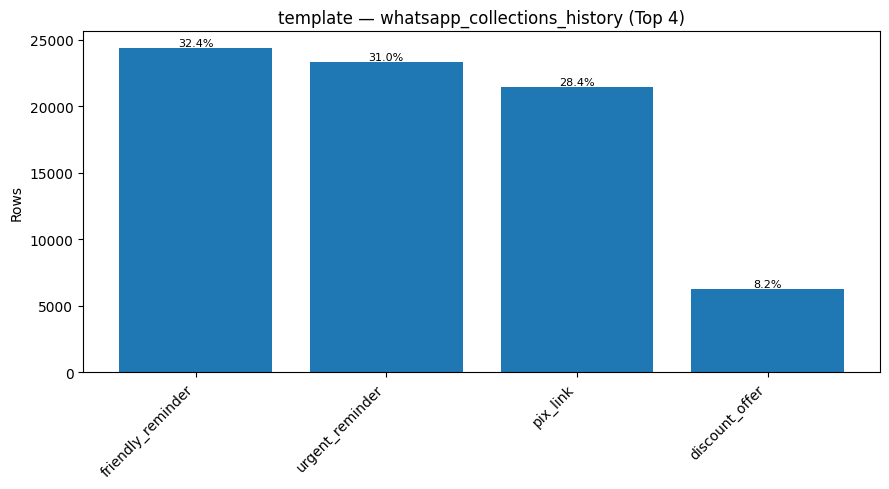

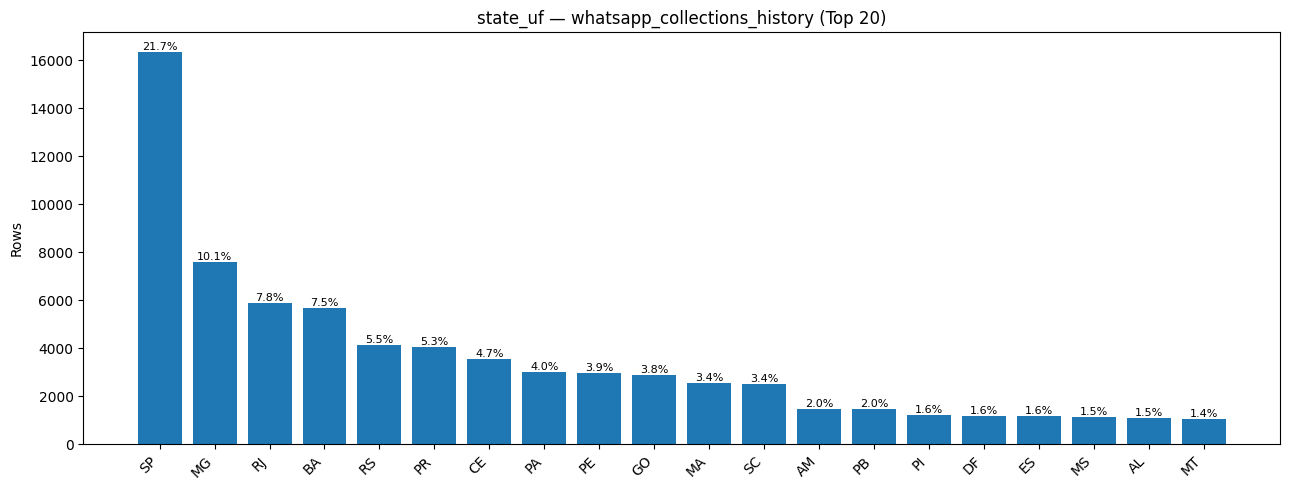

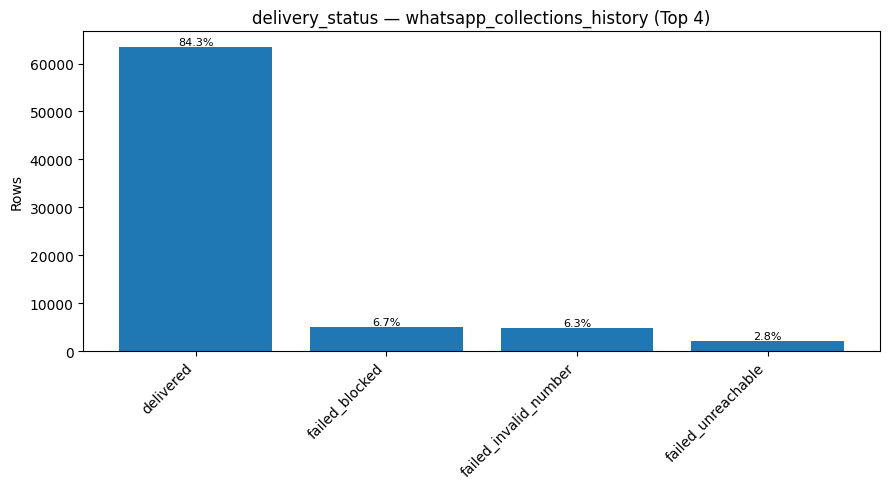

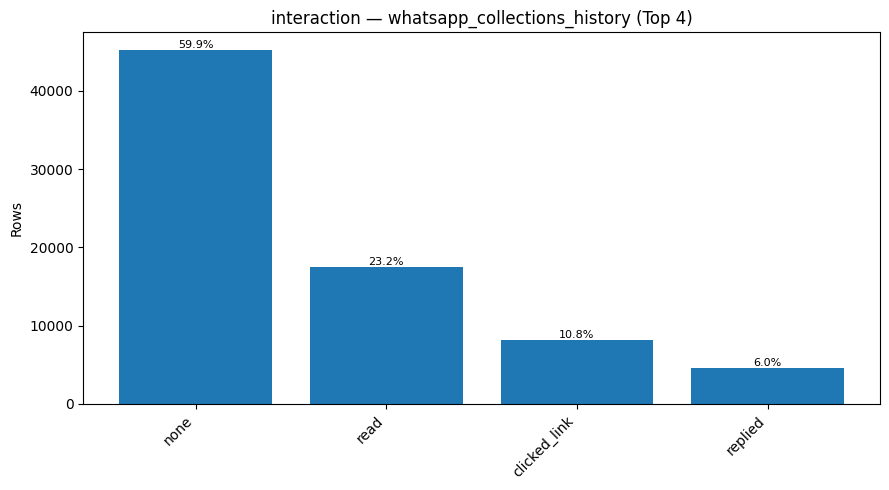

In [9]:
def plot_categorical_distribution(series, variable, dataset_name, top_n=20):
    counts = series.fillna("<MISSING>").astype(str).value_counts().head(top_n)
    if counts.empty:
        return
    pct = counts / len(series) * 100
    plt.figure(figsize=(max(9, min(14, len(counts) * .65)), 5))
    bars = plt.bar(counts.index, counts.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Rows")
    plt.title(f"{variable} — {dataset_name} (Top {min(top_n, len(counts))})")
    for bar, percentage in zip(bars, pct):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{percentage:.1f}%", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

for dataset_name, df in datasets.items():
    display(Markdown(f"### Categorical variables — {dataset_name}"))
    for variable in df.select_dtypes(include=["object", "category", "bool"]).columns:
        # Skip near-identifiers/high-cardinality free text from bar charts.
        if df[variable].nunique(dropna=True) <= min(50, max(20, int(len(df) * .10))):
            plot_categorical_distribution(df[variable], variable, dataset_name)
        else:
            print(f"{variable}: chart skipped ({df[variable].nunique(dropna=True):,} unique values)")


## 4.7 Datetime variables}

In [10]:
# ============================================================
# DATETIME DETECTION
# ============================================================

def detect_datetime_columns(df, threshold=0.90):

    detected = []

    # Common naming patterns for datetime variables
    datetime_patterns = (
        "_at",
        "_date",
        "_datetime",
        "_timestamp",
        "_since",
    )

    for col in df.columns:

        series = df[col]

        # ----------------------------------------------------
        # 1. Already datetime
        # ----------------------------------------------------
        if pd.api.types.is_datetime64_any_dtype(series):

            detected.append({
                "variable": col,
                "detection_source": "native_datetime",
            })

            continue

        # ----------------------------------------------------
        # 2. Column name suggests datetime
        # ----------------------------------------------------
        name_suggests_datetime = (
            col.lower().endswith(datetime_patterns)
            or col.lower().startswith("date_")
        )

        # ----------------------------------------------------
        # 3. Test whether values can actually be parsed
        # ----------------------------------------------------
        if (
            pd.api.types.is_object_dtype(series)
            or pd.api.types.is_string_dtype(series)
        ):

            non_null = series.dropna()

            if non_null.empty:
                continue

            parsed = pd.to_datetime(
                non_null,
                errors="coerce",
            )

            parse_rate = parsed.notna().mean()

            # Name suggests datetime AND values support it
            if name_suggests_datetime and parse_rate > 0:

                detected.append({
                    "variable": col,
                    "detection_source": "name_and_parseability",
                })

                continue

            # Even without naming evidence,
            # almost all values behave like datetime
            if parse_rate >= threshold:

                detected.append({
                    "variable": col,
                    "detection_source": "parseability",
                })

    return detected

In [11]:
# ============================================================
# DATETIME SUMMARY
# ============================================================

datetime_rows = []

for dataset_name, df in datasets.items():

    datetime_columns = detect_datetime_columns(
        df,
        threshold=0.90,
    )

    for item in datetime_columns:

        variable = item["variable"]
        detection_source = item["detection_source"]

        original = df[variable]

        # Temporary analytical representation
        parsed = pd.to_datetime(
            original,
            errors="coerce",
        )

        valid = parsed.dropna()
        original_non_null = original.notna().sum()

        datetime_rows.append({

            "dataset": dataset_name,
            "variable": variable,

            "original_dtype": str(original.dtype),
            "detection_source": detection_source,

            "non_null_original": original_non_null,

            "valid_datetime": parsed.notna().sum(),

            "invalid_datetime": (
                original.notna()
                & parsed.isna()
            ).sum(),

            "parse_success_pct": (
                parsed.notna().sum()
                / max(original_non_null, 1)
                * 100
            ),

            "missing_pct": (
                original.isna().mean() * 100
            ),

            "min_datetime": (
                valid.min()
                if not valid.empty
                else pd.NaT
            ),

            "p25_datetime": (
                valid.quantile(.25)
                if not valid.empty
                else pd.NaT
            ),

            "median_datetime": (
                valid.median()
                if not valid.empty
                else pd.NaT
            ),

            "p75_datetime": (
                valid.quantile(.75)
                if not valid.empty
                else pd.NaT
            ),

            "max_datetime": (
                valid.max()
                if not valid.empty
                else pd.NaT
            ),

            "n_unique": valid.nunique(),
        })


datetime_summary_df = pd.DataFrame(datetime_rows)

display(datetime_summary_df)

,dataset,variable,original_dtype,detection_source,non_null_original,valid_datetime,invalid_datetime,parse_success_pct,missing_pct,min_datetime,p25_datetime,median_datetime,p75_datetime,max_datetime,n_unique
0,collections_queue_sep2026,in_collections_since,object,name_and_parseability,10658,10658,0,100.0000,0.0000,2026-07-04 00:00:00,2026-08-02 00:00:00,2026-08-29 00:00:00,2026-09-14 00:00:00,2026-09-30 00:00:00,89
1,whatsapp_collections_history,sent_at,object,name_and_parseability,75406,75406,0,100.0000,0.0000,2026-06-01 09:18:00,2026-07-06 14:44:00,2026-07-26 16:44:00,2026-08-13 11:02:00,2026-08-31 20:59:00,39466


In [12]:
# ============================================================
# DATETIME VARIABLE ANALYSIS
# ============================================================

datetime_rows = []

for dataset_name, df in datasets.items():

    datetime_columns = detect_datetime_columns(
        df,
        threshold=0.90,
    )

    for item in datetime_columns:

        variable = item["variable"]
        detection_source = item["detection_source"]

        original = df[variable]

        # Temporary analytical conversion
        parsed = pd.to_datetime(
            original,
            errors="coerce",
        )

        valid = parsed.dropna()
        original_non_null = original.notna().sum()

        if valid.empty:
            continue

        datetime_rows.append({
            "dataset": dataset_name,
            "variable": variable,
            "original_dtype": str(original.dtype),
            "detection_source": detection_source,

            # Completeness / parsing
            "count": len(df),
            "non_null": original_non_null,
            "missing_pct": original.isna().mean() * 100,
            "invalid_datetime": (
                original.notna() & parsed.isna()
            ).sum(),
            "parse_success_pct": (
                parsed.notna().sum()
                / max(original_non_null, 1)
                * 100
            ),

            # Cardinality
            "n_unique": valid.nunique(),

            # Temporal range
            "min": valid.min(),
            "p25": valid.quantile(.25),
            "median": valid.median(),
            "p75": valid.quantile(.75),
            "max": valid.max(),

            # Coverage
            "range_days": (
                valid.max() - valid.min()
            ).days,

            # Concentration
            "n_unique_dates": valid.dt.date.nunique(),
            "n_unique_months": valid.dt.to_period("M").nunique(),
            "n_unique_days_of_week": valid.dt.dayofweek.nunique(),
        })


datetime_summary_df = pd.DataFrame(datetime_rows)

display(
    datetime_summary_df
    .sort_values(["dataset", "variable"])
    .reset_index(drop=True)
)

,dataset,variable,original_dtype,detection_source,count,non_null,missing_pct,invalid_datetime,parse_success_pct,n_unique,min,p25,median,p75,max,range_days,n_unique_dates,n_unique_months,n_unique_days_of_week
0,collections_queue_sep2026,in_collections_since,object,name_and_parseability,10658,10658,0.0000,0,100.0000,89,2026-07-04 00:00:00,2026-08-02 00:00:00,2026-08-29 00:00:00,2026-09-14 00:00:00,2026-09-30 00:00:00,88,89,3,7
1,whatsapp_collections_history,sent_at,object,name_and_parseability,75406,75406,0.0000,0,100.0000,39466,2026-06-01 09:18:00,2026-07-06 14:44:00,2026-07-26 16:44:00,2026-08-13 11:02:00,2026-08-31 20:59:00,91,92,3,7


### 4.7.1 Temporal distributions

In [13]:
# ============================================================
# DATETIME DISTRIBUTION PLOTS
# ============================================================

for dataset_name, df in datasets.items():

    datetime_columns = detect_datetime_columns(
        df,
        threshold=0.90,
    )

    for item in datetime_columns:

        variable = item["variable"]

        parsed = pd.to_datetime(
            df[variable],
            errors="coerce",
        ).dropna()

        if parsed.empty:
            continue

        print("\n" + "=" * 70)
        print(f"{dataset_name.upper()} — {variable}")
        print("=" * 70)

        print(f"Observations : {len(parsed):,}")
        print(f"Min          : {parsed.min()}")
        print(f"Median       : {parsed.median()}")
        print(f"Max          : {parsed.max()}")
        print(f"Unique       : {parsed.nunique():,}")



COLLECTIONS_QUEUE_SEP2026 — in_collections_since
Observations : 10,658
Min          : 2026-07-04 00:00:00
Median       : 2026-08-29 00:00:00
Max          : 2026-09-30 00:00:00
Unique       : 89

WHATSAPP_COLLECTIONS_HISTORY — sent_at
Observations : 75,406
Min          : 2026-06-01 09:18:00
Median       : 2026-07-26 16:44:00
Max          : 2026-08-31 20:59:00
Unique       : 39,466


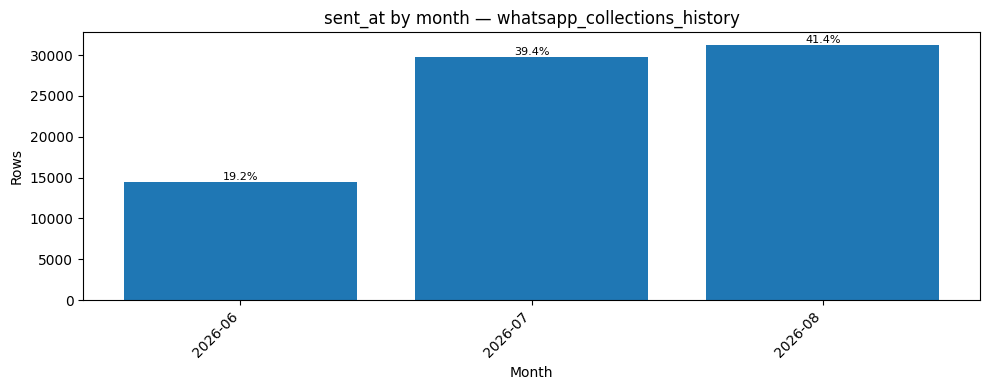

In [14]:
        # ----------------------------------------------------
        # MONTHLY DISTRIBUTION
        # ----------------------------------------------------

        monthly = (
            parsed
            .dt.to_period("M")
            .value_counts()
            .sort_index()
        )

        monthly_pct = monthly / len(parsed) * 100

        plt.figure(figsize=(10, 4))

        bars = plt.bar(
            monthly.index.astype(str),
            monthly.values,
        )

        for bar, pct in zip(bars, monthly_pct):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
            )

        plt.xlabel("Month")
        plt.ylabel("Rows")
        plt.title(
            f"{variable} by month — {dataset_name}"
        )

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

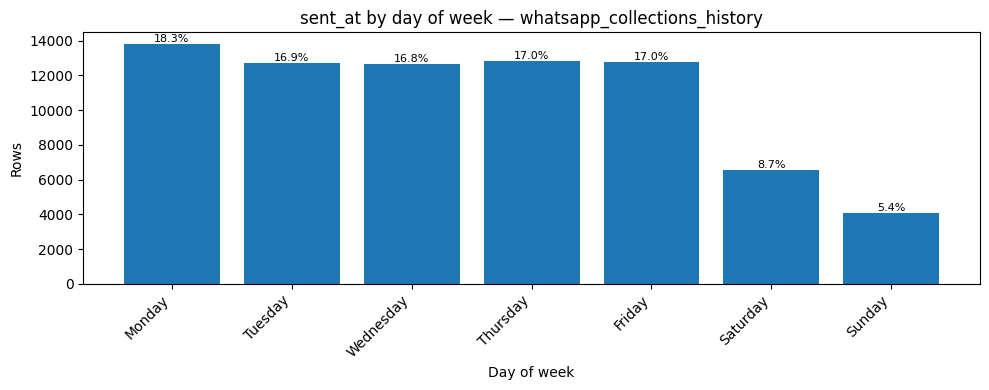

In [15]:
        # ----------------------------------------------------
        # DAY OF WEEK DISTRIBUTION
        # ----------------------------------------------------

        weekday_order = [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday",
        ]

        weekday = (
            parsed
            .dt.day_name()
            .value_counts()
            .reindex(weekday_order, fill_value=0)
        )

        weekday_pct = weekday / len(parsed) * 100

        plt.figure(figsize=(10, 4))

        bars = plt.bar(
            weekday.index,
            weekday.values,
        )

        for bar, pct in zip(bars, weekday_pct):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
            )

        plt.xlabel("Day of week")
        plt.ylabel("Rows")
        plt.title(
            f"{variable} by day of week — {dataset_name}"
        )

        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

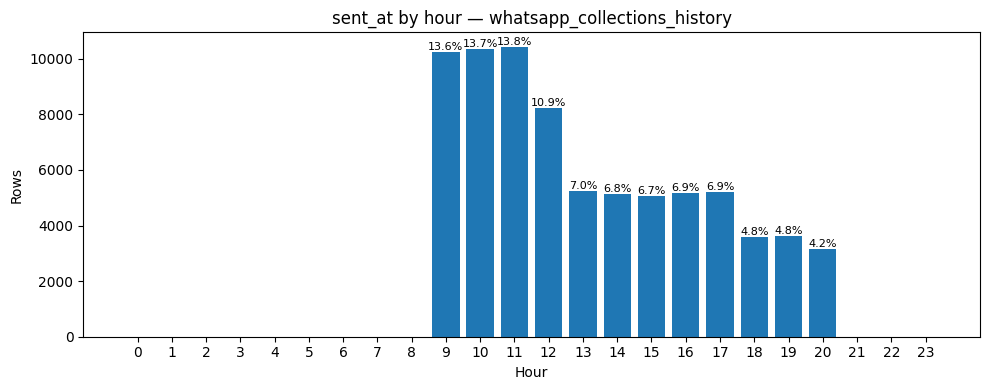

In [16]:
        # ----------------------------------------------------
        # HOUR DISTRIBUTION
        # ----------------------------------------------------

        has_time_information = (
            (parsed.dt.hour != 0)
            | (parsed.dt.minute != 0)
            | (parsed.dt.second != 0)
        ).any()

        if has_time_information:

            hourly = (
                parsed
                .dt.hour
                .value_counts()
                .reindex(range(24), fill_value=0)
            )

            hourly_pct = hourly / len(parsed) * 100

            plt.figure(figsize=(10, 4))

            bars = plt.bar(
                hourly.index,
                hourly.values,
            )

            for bar, pct in zip(bars, hourly_pct):

                if pct > 0:

                    plt.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height(),
                        f"{pct:.1f}%",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

            plt.xlabel("Hour")
            plt.ylabel("Rows")
            plt.title(
                f"{variable} by hour — {dataset_name}"
            )

            plt.xticks(range(24))
            plt.tight_layout()
            plt.show()

## 4.8 Identifier and cardinality diagnostics

In [17]:
identifier_diagnostics = variable_inventory.copy()
identifier_diagnostics["uniqueness_ratio"] = identifier_diagnostics["n_unique"] / identifier_diagnostics["non_null"].replace(0, np.nan)
identifier_diagnostics["cardinality_flag"] = np.select(
    [
        identifier_diagnostics["uniqueness_ratio"].ge(.99),
        identifier_diagnostics["unique_pct_non_null"].ge(50),
        identifier_diagnostics["n_unique"].le(1),
    ],
    ["NEAR_UNIQUE", "HIGH_CARDINALITY", "CONSTANT"],
    default="REGULAR",
)

display(identifier_diagnostics[[
    "dataset", "variable", "dtype", "non_null", "n_unique",
    "unique_pct_non_null", "cardinality_flag"
]].sort_values(["dataset", "cardinality_flag", "variable"]).reset_index(drop=True))


,dataset,variable,dtype,non_null,n_unique,unique_pct_non_null,cardinality_flag
0,collections_queue_sep2026,outstanding_balance_brl,float64,10658,9250,86.7893,HIGH_CARDINALITY
1,collections_queue_sep2026,customer_id,object,10658,10658,100.0000,NEAR_UNIQUE
2,collections_queue_sep2026,account_age_months,int64,10658,40,0.3753,REGULAR
3,collections_queue_sep2026,days_past_due_on_2026-09-01,int64,10658,60,0.5630,REGULAR
4,collections_queue_sep2026,days_since_last_app_login,int64,10658,165,1.5481,REGULAR
5,collections_queue_sep2026,in_collections_since,object,10658,89,0.8351,REGULAR
6,collections_queue_sep2026,monthly_salary_brl,float64,10658,617,5.7891,REGULAR
7,collections_queue_sep2026,n_prior_transactions,int64,10658,40,0.3753,REGULAR
8,collections_queue_sep2026,payday_day_of_month,int64,10658,7,0.0657,REGULAR
9,collections_queue_sep2026,state_uf,object,10658,27,0.2533,REGULAR


## 4.9 Concentration analysis

Quantifies how much of each variable is concentrated in its most frequent observed values. High concentration may indicate near-constant variables, dominant categories, spikes, or operational defaults that deserve later investigation.

In [18]:
concentration_rows = []
for dataset_name, df in datasets.items():
    for variable in df.columns:
        valid = df[variable].dropna()
        if valid.empty:
            continue
        shares = valid.value_counts(normalize=True, dropna=False)
        concentration_rows.append({
            "dataset": dataset_name,
            "variable": variable,
            "n_unique": valid.nunique(),
            "top_1_pct": shares.iloc[:1].sum() * 100,
            "top_3_pct": shares.iloc[:3].sum() * 100,
            "top_5_pct": shares.iloc[:5].sum() * 100,
            "top_10_pct": shares.iloc[:10].sum() * 100,
        })

concentration_df = pd.DataFrame(concentration_rows)
display(concentration_df.sort_values(["dataset", "top_1_pct"], ascending=[True, False]).reset_index(drop=True))


,dataset,variable,n_unique,top_1_pct,top_3_pct,top_5_pct,top_10_pct
0,collections_queue_sep2026,days_past_due_on_2026-09-01,60,46.9131,49.3714,51.6795,57.1308
1,collections_queue_sep2026,payday_day_of_month,7,35.4100,61.8127,82.4920,100.0000
2,collections_queue_sep2026,state_uf,27,22.1336,40.1764,52.8898,74.3291
3,collections_queue_sep2026,n_prior_transactions,40,11.6814,30.6999,45.1117,69.3470
4,collections_queue_sep2026,account_age_months,40,9.4014,24.6482,38.5720,66.9169
5,collections_queue_sep2026,monthly_salary_brl,617,6.6710,7.6656,8.6320,10.9964
6,collections_queue_sep2026,days_since_last_app_login,165,4.3066,11.9159,19.0092,33.4303
7,collections_queue_sep2026,outstanding_balance_brl,9250,4.1190,4.3629,4.5975,5.1229
8,collections_queue_sep2026,in_collections_since,89,1.8015,5.1886,8.5194,16.7198
9,collections_queue_sep2026,customer_id,10658,0.0094,0.0281,0.0469,0.0938


## 4.10 Variable-level EDA function

A compact function for drilling into one variable without mixing in business interpretation.

In [19]:
def eda_variable(variable, dataset_name=None, top_n=20, plot=True):
    locations = [(name, df) for name, df in datasets.items() if variable in df.columns]
    if dataset_name is not None:
        locations = [(name, df) for name, df in locations if name == dataset_name]
    if not locations:
        raise KeyError(f"Variable not found: {variable}")

    for name, df in locations:
        s = df[variable]
        display(Markdown(f"### `{variable}` — {name}"))
        overview = pd.DataFrame([{
            "dtype": str(s.dtype), "rows": len(s), "non_null": s.notna().sum(),
            "missing_pct": s.isna().mean()*100, "n_unique": s.nunique(dropna=True),
            "unique_pct_non_null": s.nunique(dropna=True)/max(s.notna().sum(),1)*100,
        }])
        display(overview)

        if pd.api.types.is_numeric_dtype(s):
            display(pd.DataFrame([numeric_summary(s)]))
            display(s.value_counts(dropna=False).head(top_n).rename("count").to_frame())
            if plot:
                plot_numeric_distribution(s, variable, name)
        else:
            display(pd.DataFrame([categorical_summary(s)]))
            counts = s.fillna("<MISSING>").astype(str).value_counts().head(top_n)
            detail = pd.DataFrame({"count": counts, "pct_rows": counts/len(s)*100})
            display(detail)
            if plot and s.nunique(dropna=True) <= 50:
                plot_categorical_distribution(s, variable, name, top_n=top_n)


## 4.11 Automated profiling — YData Profiling

YData Profiling is used as a complementary automated diagnostic.

In [20]:
try:
    from ydata_profiling import ProfileReport
    YDATA_AVAILABLE = True
except ImportError:
    YDATA_AVAILABLE = False
    print("ydata-profiling is not installed. Run: pip install ydata-profiling")

if YDATA_AVAILABLE:
    for dataset_name, df in datasets.items():
        output_path = REPORT_DIR / f"{dataset_name}_ydata.html"
        profile = ProfileReport(
            df,
            title=f"Univariate EDA — {dataset_name}",
            explorative=True,
            minimal=False,
        )
        profile.to_file(output_path)
        print("Saved:", output_path)


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 59.35it/s]


Saved: ..\reports\eda\collections_queue_sep2026_ydata.html


Export report to file: 100%|██████████| 1/1 [00:00<00:00, 45.06it/s]

Saved: ..\reports\eda\whatsapp_collections_history_ydata.html


## 4.12 Automated profiling — Sweetviz

Sweetviz provides a second visual profiling view for each dataset

In [21]:
try:
    import sweetviz as sv
    SWEETVIZ_AVAILABLE = True
except ImportError:
    SWEETVIZ_AVAILABLE = False
    print("sweetviz is not installed. Run: pip install sweetviz")

if SWEETVIZ_AVAILABLE:
    for dataset_name, df in datasets.items():
        output_path = REPORT_DIR / f"{dataset_name}_sweetviz.html"
        report = sv.analyze(df)
        report.show_html(str(output_path), open_browser=False)
        print("Saved:", output_path)


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report ..\reports\eda\collections_queue_sep2026_sweetviz.html was generated.
Saved: ..\reports\eda\collections_queue_sep2026_sweetviz.html


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report ..\reports\eda\whatsapp_collections_history_sweetviz.html was generated.
Saved: ..\reports\eda\whatsapp_collections_history_sweetviz.html


## 4.13 EDA summary

In [22]:
eda_summary = variable_inventory.merge(
    concentration_df[["dataset", "variable", "top_1_pct", "top_3_pct", "top_5_pct"]],
    on=["dataset", "variable"], how="left"
)

eda_summary["eda_flags"] = eda_summary.apply(
    lambda r: ", ".join([
        flag for flag, condition in [
            ("ALL_MISSING", r["is_all_missing"]),
            ("CONSTANT", r["is_constant"]),
            ("HIGH_MISSING", r["missing_pct"] >= 50),
            ("HIGH_CONCENTRATION", pd.notna(r["top_1_pct"]) and r["top_1_pct"] >= 95),
            ("NEAR_UNIQUE", pd.notna(r["unique_pct_non_null"]) and r["unique_pct_non_null"] >= 99),
        ] if condition
    ]) or "NONE",
    axis=1,
)

display(
    eda_summary[[
        "dataset", "variable", "dtype", "missing_pct", "n_unique",
        "unique_pct_non_null", "top_1_pct", "top_3_pct", "top_5_pct", "eda_flags"
    ]].sort_values(["dataset", "eda_flags", "variable"]).reset_index(drop=True)
)


,dataset,variable,dtype,missing_pct,n_unique,unique_pct_non_null,top_1_pct,top_3_pct,top_5_pct,eda_flags
0,collections_queue_sep2026,customer_id,object,0.0000,10658,100.0000,0.0094,0.0281,0.0469,NEAR_UNIQUE
1,collections_queue_sep2026,account_age_months,int64,0.0000,40,0.3753,9.4014,24.6482,38.5720,NONE
2,collections_queue_sep2026,days_past_due_on_2026-09-01,int64,0.0000,60,0.5630,46.9131,49.3714,51.6795,NONE
3,collections_queue_sep2026,days_since_last_app_login,int64,0.0000,165,1.5481,4.3066,11.9159,19.0092,NONE
4,collections_queue_sep2026,in_collections_since,object,0.0000,89,0.8351,1.8015,5.1886,8.5194,NONE
5,collections_queue_sep2026,monthly_salary_brl,float64,0.0000,617,5.7891,6.6710,7.6656,8.6320,NONE
6,collections_queue_sep2026,n_prior_transactions,int64,0.0000,40,0.3753,11.6814,30.6999,45.1117,NONE
7,collections_queue_sep2026,outstanding_balance_brl,float64,0.0000,9250,86.7893,4.1190,4.3629,4.5975,NONE
8,collections_queue_sep2026,payday_day_of_month,int64,0.0000,7,0.0657,35.4100,61.8127,82.4920,NONE
9,collections_queue_sep2026,state_uf,object,0.0000,27,0.2533,22.1336,40.1764,52.8898,NONE
